# Ghouls, Goblins, and Ghosts... Boo! 
<img src='images/ggg.png' height=90% width=90%>

The data set consists of the following columns.
# Data fields
* id - id of the creature
* bone_length - average length of bone in the creature, normalized between 0 and 1
* rotting_flesh - percentage of rotting flesh in the creature
* hair_length - average hair length, normalized between 0 and 1
* has_soul - percentage of soul in the creature
* color - dominant color of the creature: 'white', 'black', 'clear', 'blue', 'green', and 'blood'
* type - target variable: 'Ghost', 'Goblin', and 'Ghoul'

In [2]:
# import libaries
import pandas as pd
# load data
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample_submission = pd.read_csv('sample_submission.csv')

# Summarize Data

In [3]:
# shape
print('The dataset has %d rows and %d columns. \n' % (train.shape[0], train.shape[1]))

The dataset has 371 rows and 7 columns. 



In [4]:
# info
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 371 entries, 0 to 370
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             371 non-null    int64  
 1   bone_length    371 non-null    float64
 2   rotting_flesh  371 non-null    float64
 3   hair_length    371 non-null    float64
 4   has_soul       371 non-null    float64
 5   color          371 non-null    object 
 6   type           371 non-null    object 
dtypes: float64(4), int64(1), object(2)
memory usage: 20.4+ KB


In [5]:
# data types of columns
train.dtypes

id                 int64
bone_length      float64
rotting_flesh    float64
hair_length      float64
has_soul         float64
color             object
type              object
dtype: object

# Categorical Features
There are only 2 categorical columns in the data set, one of which is the target variable. The only categorical feature is color and it costs of 6 unique values with 'white' being the top colors occuring 137 times.

In [6]:
# cet categorical columns
categorical_features = list(train.drop(['id'], axis='columns').select_dtypes(include=['object', 'bool']).columns)

In [7]:
train[categorical_features].describe()

,color,type
count,371,371
unique,6,3
top,white,Ghoul
freq,137,129


## Chisq Test
With only two categorical variables, a chisq test is performed on their relationship. Based on the test, the variables are found to be independent. Looking at the contigency table, the colors match up fairly evenly across each type. Given the color of a creature, one can not distinguish the type of ghost.

In [8]:
# import chisq
from scipy.stats import chi2_contingency
# chisq on crosstab
def get_chi_sq(feature1, feature2):
    print('Contigency Table of \'{}\' and \'{}\'.'.format(feature1, feature2))
    display(pd.crosstab(train[feature1], train[feature2], margins=True))
    print('Contigency Table of \'{}\' and \'{}\' with percentages.'.format(feature1, feature2))
    display(pd.crosstab(train[feature1], train[feature2], normalize=True, margins=True))
    test_statistic, p_value, dof, expected = chi2_contingency(pd.crosstab(train[feature1], train[feature2]))
    if p_value < 0.05:
        print('The features of \'{}\' and \'{}\' are {} with a p-value of {:.4f}.'.format(feature1, feature2, 'dependent', p_value))
    else:
        print('The features of \'{}\' and \'{}\' are {} with a p-value of {:.4f}.'.format(feature1, feature2, 'independent', p_value))

get_chi_sq('type', 'color')

Contigency Table of 'type' and 'color'.


color,black,blood,blue,clear,green,white,All
type,,,,,,,
Ghost,14,6,6,32,15,44,117
Ghoul,14,4,6,42,13,50,129
Goblin,13,2,7,46,14,43,125
All,41,12,19,120,42,137,371


Contigency Table of 'type' and 'color' with percentages.


color,black,blood,blue,clear,green,white,All
type,,,,,,,
Ghost,0.037736,0.016173,0.016173,0.086253,0.040431,0.118598,0.315364
Ghoul,0.037736,0.010782,0.016173,0.113208,0.035040,0.134771,0.347709
Goblin,0.035040,0.005391,0.018868,0.123989,0.037736,0.115903,0.336927
All,0.110512,0.032345,0.051213,0.323450,0.113208,0.369272,1.000000


The features of 'type' and 'color' are independent with a p-value of 0.8899.


## Countplots
The following are count plots of the two categorical columns. With respect to color, White is the most dominant, followed by clear. For the type of creature, the target variable is fairly evenly distributed.

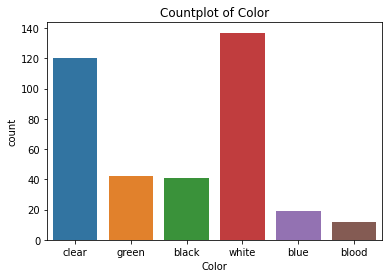

       color
white    137
clear    120
green     42
black     41
blue      19
blood     12


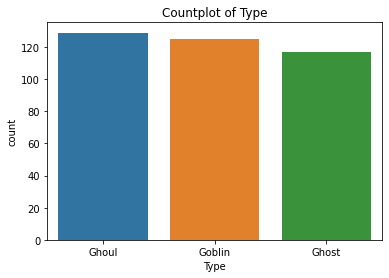

        type
Ghoul    129
Goblin   125
Ghost    117


In [11]:
# import libraries
import seaborn as sns
import matplotlib.pyplot as plt
# count plots
for feature in categorical_features:
    sns.countplot(x=feature, data=train)
    plt.title('Countplot of {}'.format(feature.capitalize()))
    plt.xlabel(feature.capitalize())
    plt.show()
    print(pd.DataFrame(train[feature].value_counts()))

# Numeric Features
The majority of the features are numeric. The count, mean, standard deviation, min, [25th, 50th, 75th] percentile and maximum values are shown.

In [54]:
# get numeric columns
numeric_features = list(train.drop(['id'], axis='columns').select_dtypes(include=['int64', 'float64']).columns)

In [55]:
# description
display(train[numeric_features].describe())

,bone_length,rotting_flesh,hair_length,has_soul
count,371.000000,371.000000,371.000000,371.000000
mean,0.434160,0.506848,0.529114,0.471392
std,0.132833,0.146358,0.169902,0.176129
min,0.061032,0.095687,0.134600,0.009402
25%,0.340006,0.414812,0.407428,0.348002
50%,0.434891,0.501552,0.538642,0.466372
75%,0.517223,0.603977,0.647244,0.600610
max,0.817001,0.932466,1.000000,0.935721


Additionally, a table of correlations and a heat map of the correlations. There is a fairly weak relationship between the features.

,bone_length,rotting_flesh,hair_length,has_soul
bone_length,1.000000,-0.041716,0.353881,0.381675
rotting_flesh,-0.041716,1.000000,-0.220353,-0.132051
hair_length,0.353881,-0.220353,1.000000,0.474835
has_soul,0.381675,-0.132051,0.474835,1.000000


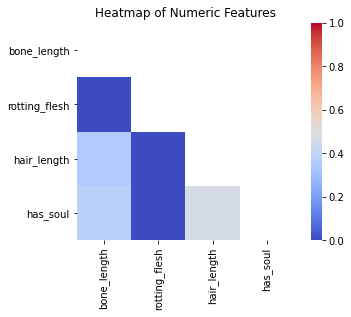

In [56]:
# correlation
display(train[numeric_features].corr())
# import libraries
import numpy as np
# heatmap
corr = train[numeric_features].corr()
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr, vmin=0, vmax=1, mask=mask, square=True, cmap='coolwarm')
plt.title('Heatmap of Numeric Features')
plt.show()

## Normality and Graphs
For each of the numeric features, a Shapiro–Wilk test is done and the data are graphed in a histogram with a kde. The Shapiro–Wilk test is a test of normality and the null hypothesis is normality with the alternative being not normal. Based on the tests, all the data are normally distributed.

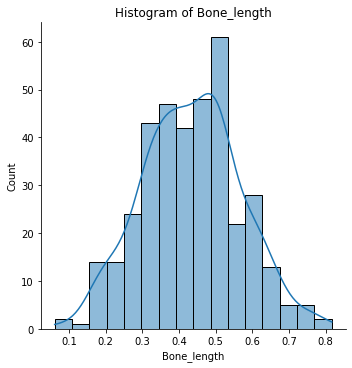

'bone_length' is normally distributed with a p-value of 0.7025.


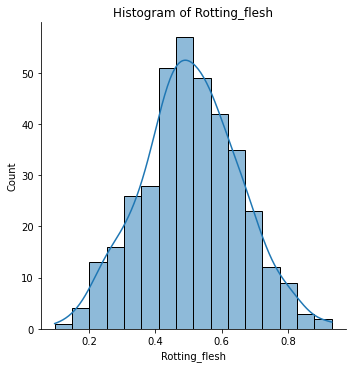

'rotting_flesh' is normally distributed with a p-value of 0.9133.


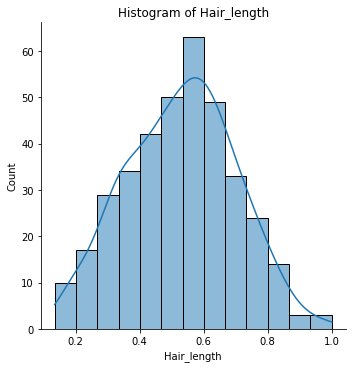

'hair_length' is normally distributed with a p-value of 0.1455.


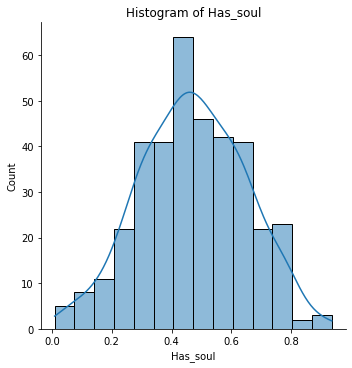

'has_soul' is normally distributed with a p-value of 0.5923.


In [57]:
# import libaries
from scipy.stats import shapiro
# test for normality and graphs
for feature in numeric_features:
    sns.displot(train[feature], kde=True)
    title = 'Histogram of ' + feature.capitalize()
    plt.title(title)
    plt.xlabel(feature.capitalize())
    plt.show()
    if shapiro(train[feature])[1] >= 0.05:
        print('\'{}\' is normally distributed with a p-value of {:.4f}.'.format(feature, shapiro(train[feature])[1]))
    else:
        print('\'{}\' is not normally distributed with a p-value of {:.4f}.'.format(feature, shapiro(train[feature])[1]))

## Pairplot
A pairplot is done across all the numeric features and it is colored based on the type of creature.

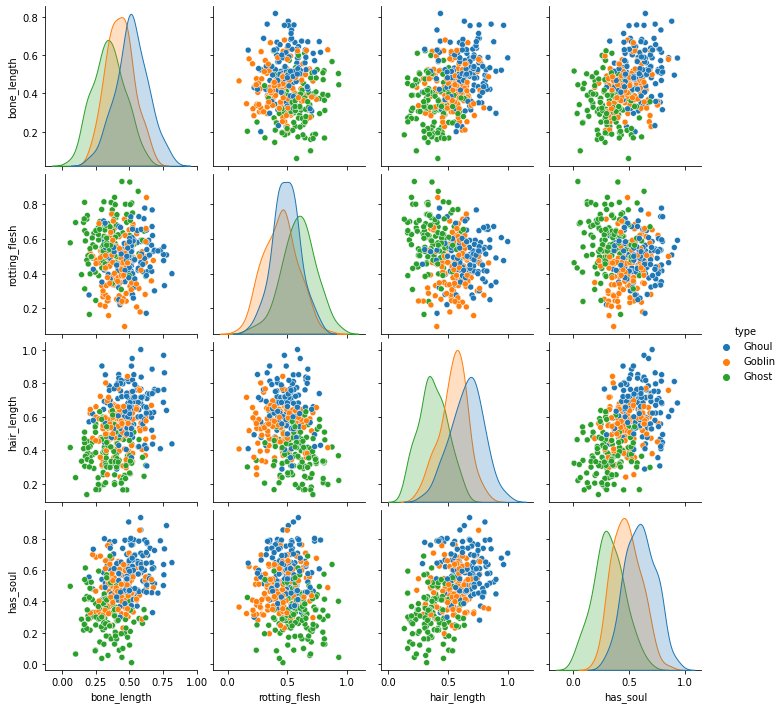

In [58]:
# pairplot
sns.pairplot(train.drop(['id'], axis='columns'), hue='type')
plt.show()

# Analysis of Variation
Analysis of variance (ANOVA) is done for for each numeric feature and the target variable 'type'. Based on all tests, there exist a statistical significant difference across types for each numeric feature. Additionally, all the pair-wise comparisons within each test also show a statistical significant difference.

In [59]:
# import libraries
import statsmodels.api as sm
from statsmodels.formula.api import ols
# Function for Anova
def aov(num, cat):
    num = num
    cat = cat
    formula = num + ' ~ ' + cat
    mod = ols(formula, data=train).fit()
                    
    aov_table = sm.stats.anova_lm(mod, typ=2)
    sns.boxplot(x=cat, y=num, data=train, width=0.2)
    plt.title('Boxplot of {} by {}'.format(num.capitalize(), cat.capitalize()))
    plt.ylabel(num.capitalize())
    plt.xlabel(cat.capitalize())
    plt.show()
    display('Means by Group:')
    display(train.groupby(cat, as_index=False)[num].mean())
    display('AOV Results:')
    display(aov_table)

    display('Pairwise Comparisons:')
    pair_t = mod.t_test_pairwise(cat)
    display(pair_t.result_frame)
    

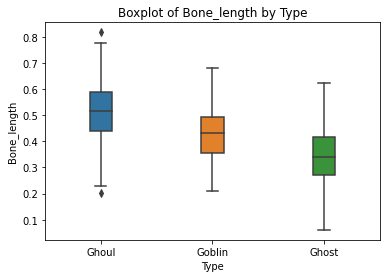

'Means by Group:'

,type,bone_length
0,Ghost,0.347466
1,Ghoul,0.517159
2,Goblin,0.429650


'AOV Results:'

,sum_sq,df,F,PR(>F)
type,1.770561,2.0,68.471373,5.241376e-26
Residual,4.757948,368.0,NaN,NaN


'Pairwise Comparisons:'

,coef,std err,t,P>|t|,Conf. Int. Low,Conf. Int. Upp.,pvalue-hs,reject-hs
Ghoul-Ghost,0.169693,0.014517,11.689577,4.631235e-27,0.141147,0.198239,0.000000e+00,True
Goblin-Ghost,0.082184,0.014627,5.618794,3.800754e-08,0.053422,0.110947,3.800754e-08,True
Goblin-Ghoul,-0.087509,0.014271,-6.131963,2.239448e-09,-0.115572,-0.059446,4.478896e-09,True


In [60]:
aov('bone_length', 'type')

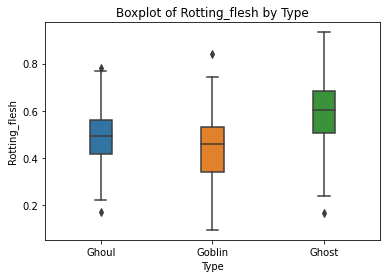

'Means by Group:'

,type,rotting_flesh
0,Ghost,0.593759
1,Ghoul,0.490515
2,Goblin,0.442357


'AOV Results:'

,sum_sq,df,F,PR(>F)
type,1.438056,2.0,40.786083,1.002089e-16
Residual,6.487562,368.0,NaN,NaN


'Pairwise Comparisons:'

,coef,std err,t,P>|t|,Conf. Int. Low,Conf. Int. Upp.,pvalue-hs,reject-hs
Ghoul-Ghost,-0.103244,0.016951,-6.090722,2.831633e-09,-0.136577,-0.069911,5.663267e-09,True
Goblin-Ghost,-0.151402,0.017080,-8.864494,3.352350e-17,-0.184987,-0.117816,0.000000e+00,True
Goblin-Ghoul,-0.048157,0.016664,-2.889882,4.082232e-03,-0.080926,-0.015389,4.082232e-03,True


In [61]:
aov('rotting_flesh', 'type')

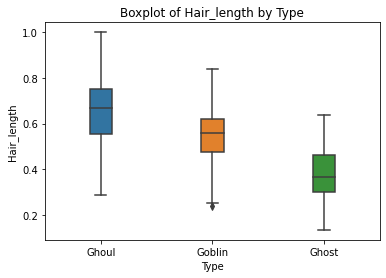

'Means by Group:'

,type,hair_length
0,Ghost,0.373186
1,Ghoul,0.655550
2,Goblin,0.544581


'AOV Results:'

,sum_sq,df,F,PR(>F)
type,4.936778,2.0,158.145351,2.702223e-50
Residual,5.743875,368.0,NaN,NaN


'Pairwise Comparisons:'

,coef,std err,t,P>|t|,Conf. Int. Low,Conf. Int. Upp.,pvalue-hs,reject-hs
Ghoul-Ghost,0.282364,0.015950,17.703147,3.596199e-51,0.250999,0.313728,0.000000e+00,True
Goblin-Ghost,0.171395,0.016071,10.664949,2.551070e-23,0.139792,0.202997,0.000000e+00,True
Goblin-Ghoul,-0.110969,0.015680,-7.077118,7.489653e-12,-0.141803,-0.080135,7.489676e-12,True


In [62]:
aov('hair_length', 'type')

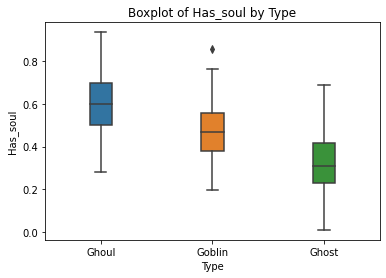

'Means by Group:'

,type,has_soul
0,Ghost,0.320023
1,Ghoul,0.601634
2,Goblin,0.478663


'AOV Results:'

,sum_sq,df,F,PR(>F)
type,4.875614,2.0,135.877682,6.448139e-45
Residual,6.602357,368.0,NaN,NaN


'Pairwise Comparisons:'

,coef,std err,t,P>|t|,Conf. Int. Low,Conf. Int. Upp.,pvalue-hs,reject-hs
Ghoul-Ghost,0.281611,0.017100,16.468147,4.810254e-46,0.247985,0.315238,0.000000e+00,True
Goblin-Ghost,0.158640,0.017230,9.207190,2.580346e-18,0.124758,0.192522,0.000000e+00,True
Goblin-Ghoul,-0.122971,0.016811,-7.314953,1.624832e-12,-0.156029,-0.089914,1.624811e-12,True


In [63]:
aov('has_soul', 'type')

# Data Cleaning
Dropping the id column. Also dropping 'color' because the chisq test showed it is indepedent from type and offers no predictive power.

In [64]:
# Drop id
train.drop(['id'], axis='columns', inplace=True)
test.drop(['id'], axis='columns', inplace=True)

# Drop color
train.drop(['color'], axis='columns', inplace=True)
test.drop(['color'], axis='columns', inplace=True)

# Model Set Ups
* Splitting the data into X, y
* Initializing the label encoder and label encoding the target
* Train/Validation split of 70/30
* Seperating the columns into numeric and categorical features.
* Creating a numeric pipeline that performs polynomial features up to the 4th degree. This includes all features from x, x^2, x^3, and x^4 and all the interactions between those and the other numeric features.

In [65]:
# Split into X, y
X = train.drop(['type'], axis='columns')
y = train['type']

# Label Encode y
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

# Train & Validation Sets
from sklearn.model_selection import train_test_split
X_train, X_validate, y_train, y_validate = train_test_split(X, y, stratify=y,test_size=0.30)

# Separate Columns by type
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'category']).columns

# Numeric Feature Pipeline (Poly)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

# numeric pipeline
numeric_pipeline_steps = []
numeric_pipeline_steps.append(('poly', PolynomialFeatures(degree=4)))
numeric_pipeline = Pipeline(steps=numeric_pipeline_steps)

# Preprocessing Transformer
preprocessing_transformer_steps = []
preprocessing_transformer_steps.append(('poly', numeric_pipeline, numeric_features))
preprocessing_transformer=ColumnTransformer(transformers=preprocessing_transformer_steps)

# Display Transformer
from sklearn import set_config
set_config(display='diagram')
preprocessing_transformer

ColumnTransformer(transformers=[('poly',
                                 Pipeline(steps=[('poly',
                                                  PolynomialFeatures(degree=4))]),
                                 Index(['bone_length', 'rotting_flesh', 'hair_length', 'has_soul'], dtype='object'))])

# Spot-Check Algorithms
* Creating a empty dataframe
* Using 'accuracy' as the scoring metric
* Initializing the following models:
    * Logistic Regression
    * Gradient Booting Classifier
    * Light Gradient Boosting Classifier
    * Xtreme Gradient Boosting Classifier
    * Random Forest Classifier
    * ADA Boost Classifier
    * Dummy Classifier (Baseline)
    * Linear Discriminant Analysis
    * K-Nearest Neighbors Classifier
    * Radius based K-Nearest Neighbors Classifier
    * Nearest Centroid
    * Support Vector Machine with Linear Kernel
    * Support Vector Machine with Radial Kernel
    * Support Vector Machine with Poly Kernel
    * Support Vector Machine with Sigmoid Kernel

For each model, a 10-fold stratified CV is performed and the results are stored in an empty dataframe. For each model, the mean of the CV is printed along with its standard deviation.

In [66]:
# Store Results
results = pd.DataFrame()
scoring = 'accuracy'

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedShuffleSplit, cross_val_score
from sklearn.dummy import DummyClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier, NearestCentroid
from sklearn.svm import SVC
models = []
models.append(('lr', LogisticRegression(solver='liblinear')))
models.append(('gbr', GradientBoostingClassifier()))
models.append(('lgbm', LGBMClassifier()))
models.append(('xgb', XGBClassifier(objective='multi:softprob', eval_metric=('mlogloss'), use_label_encoder=False)))
models.append(('rf', RandomForestClassifier()))
models.append(('ada', AdaBoostClassifier()))
models.append(('dum', DummyClassifier(strategy='stratified')))
models.append(('lda', LinearDiscriminantAnalysis()))
models.append(('knc', KNeighborsClassifier()))
models.append(('rnc', RadiusNeighborsClassifier()))
models.append(('nc', NearestCentroid()))
models.append(('svl', SVC(kernel='linear')))
models.append(('svr', SVC(kernel='rbf')))
models.append(('svp', SVC(kernel='poly')))
models.append(('svs', SVC(kernel='sigmoid')))

for name, model in models:
    # CV
    cv = StratifiedShuffleSplit(n_splits=10)
    # Pipeline
    model_pipeline_steps = []
    model_pipeline_steps.append(('transformer', preprocessing_transformer))
    model_pipeline_steps.append(('model', model))
    model_pipeline = Pipeline(steps=model_pipeline_steps)
    # CV results
    cv_results = cross_val_score(model_pipeline, X_train, y_train, cv=cv, scoring=scoring)
    # Append Results
    temp_df = pd.DataFrame({name: pd.Series(cv_results)})
    results = pd.concat([results, temp_df], axis='columns')
    # Results Mean +/- std
    msg = "%s: %f +/- %f" % (name, cv_results.mean(), cv_results.std())
    # Print Results
    print(msg)

lr: 0.707692 +/- 0.075369
gbr: 0.746154 +/- 0.057564
lgbm: 0.707692 +/- 0.069231
xgb: 0.746154 +/- 0.082849
rf: 0.738462 +/- 0.115128
ada: 0.565385 +/- 0.111538
dum: 0.384615 +/- 0.133235
lda: 0.650000 +/- 0.085051
knc: 0.753846 +/- 0.071336
rnc: 0.742308 +/- 0.078916
nc: 0.753846 +/- 0.073380
svl: 0.773077 +/- 0.128083
svr: 0.723077 +/- 0.061538
svp: 0.765385 +/- 0.065385
svs: 0.357692 +/- 0.082580


## Boxplot of Spot-Check Algorithms
A boxplot and dataframe of the results.

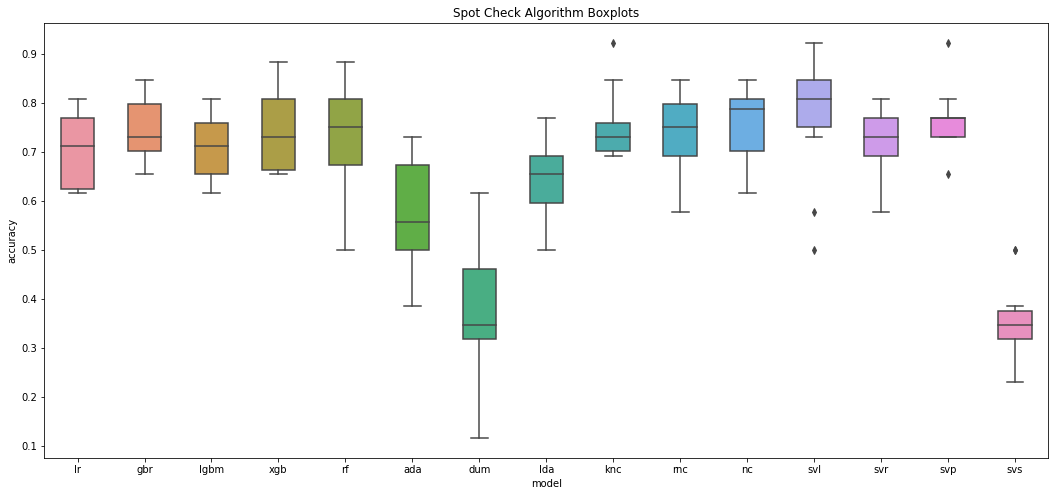

,lr,gbr,lgbm,xgb,rf,ada,dum,lda,knc,rnc,nc,svl,svr,svp,svs
0,0.692308,0.692308,0.807692,0.769231,0.807692,0.615385,0.538462,0.538462,0.692308,0.846154,0.846154,0.807692,0.769231,0.653846,0.307692
1,0.769231,0.730769,0.692308,0.692308,0.769231,0.576923,0.307692,0.692308,0.730769,0.769231,0.730769,0.807692,0.576923,0.923077,0.346154
2,0.807692,0.730769,0.730769,0.653846,0.884615,0.692308,0.461538,0.500000,0.923077,0.692308,0.807692,0.923077,0.692308,0.730769,0.346154
3,0.615385,0.769231,0.807692,0.692308,0.500000,0.500000,0.461538,0.576923,0.730769,0.692308,0.653846,0.884615,0.769231,0.769231,0.346154
4,0.615385,0.807692,0.653846,0.807692,0.730769,0.500000,0.346154,0.769231,0.730769,0.807692,0.769231,0.846154,0.692308,0.807692,0.500000
5,0.730769,0.653846,0.615385,0.884615,0.807692,0.692308,0.307692,0.692308,0.846154,0.769231,0.807692,0.500000,0.730769,0.730769,0.384615
6,0.615385,0.730769,0.730769,0.846154,0.884615,0.384615,0.615385,0.653846,0.769231,0.730769,0.807692,0.846154,0.769231,0.730769,0.346154
7,0.807692,0.807692,0.615385,0.807692,0.730769,0.730769,0.346154,0.769231,0.692308,0.692308,0.807692,0.807692,0.807692,0.769231,0.269231
8,0.653846,0.692308,0.653846,0.653846,0.653846,0.423077,0.115385,0.653846,0.692308,0.846154,0.692308,0.576923,0.692308,0.769231,0.500000
9,0.769231,0.846154,0.769231,0.653846,0.615385,0.538462,0.346154,0.653846,0.730769,0.576923,0.615385,0.730769,0.730769,0.769231,0.230769


In [67]:
# Algorithm Comparison Boxplot
plt.figure(figsize=(18,8))
sns.boxplot(x='model', y='accuracy',
            width=0.5,
            data=pd.melt(results, var_name='model', value_name='accuracy'))
plt.title('Spot Check Algorithm Boxplots')
plt.show()
display(results)

# Voting Classifier
A hard voting classifier of the top 7 models. 7 Models were chosen because an odd number was needed in case there was a tie. The models chosen are:
    * Support Vector Machine with Radial Kernel
    * Logistic Regression
    * Support Vector Machine with Linear Kernel
    * Random Forest Classifier
    * Support Vector Machine with Poly Kernel
    * Light Gradient Boosting Classifier
    * K-Nearest Neighbors Classifier

Again, a 10-fold CV was done and its results are printed.

In [ ]:
from sklearn.ensemble import VotingClassifier
estimators = []
estimators.append(('svr', SVC(kernel='rbf')))
estimators.append(('lr', LogisticRegression(solver='liblinear')))
estimators.append(('svl', SVC(kernel='linear')))
estimators.append(('rf', RandomForestClassifier()))
estimators.append(('svp', SVC(kernel='poly')))
estimators.append(('lgbm', LGBMClassifier()))
estimators.append(('knc', KNeighborsClassifier()))
vc = VotingClassifier(estimators=estimators, voting='hard')
cv = StratifiedShuffleSplit(n_splits=10)

# Pipeline
model_pipeline_steps = []
model_pipeline_steps.append(('transformer', preprocessing_transformer))
model_pipeline_steps.append(('model', vc))
model_pipeline = Pipeline(steps=model_pipeline_steps)
# CV results
cv_results = cross_val_score(model_pipeline, X_train, y_train, cv=cv, scoring=scoring)

# Results Mean +/- std
msg = "%s: %f +/- %f" % ('voting classifier', cv_results.mean(), cv_results.std())

# Print Results
print(msg)

voting classifier: 0.746154 +/- 0.057564


## Fit on Train
Fitting the voting classifier on the training set.

In [ ]:
# fit on train
model_pipeline_steps = []
model_pipeline_steps.append(('transformer', preprocessing_transformer))
model_pipeline_steps.append(('model', vc))
validation_model = Pipeline(steps=model_pipeline_steps)
validation_model.fit(X_train, y_train)

## Predictions on Validation Set
The model is then used to predict the values on the validation set and a confusion matrix is constructed. There is an accuracy of 75.8% on the validation set. The accuracy on the training set was 74.6% It did not overfit and surprisingly underfit.

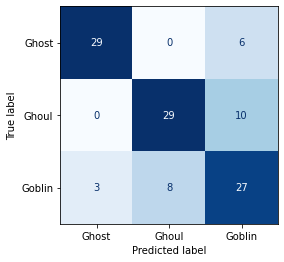

Accuracy on Validation Set: 0.758929


In [ ]:
# Confusion Matrix
from sklearn.metrics import plot_confusion_matrix
plot_confusion_matrix(validation_model,
                      X_validate,
                      y_validate,
                      cmap=plt.cm.Blues,
                      display_labels=list(le.classes_),
                      colorbar=False)
plt.show()

# Accuracy on Validation Set
from sklearn.metrics import accuracy_score
print('Accuracy on Validation Set: %f' % accuracy_score(y_validate, validation_model.predict(X_validate)))

# Model on Entire Training Set
A model is built on the entire training set and it used to predict the test set for submission.

In [ ]:
# fit on entire data set
model_pipeline_steps = []
model_pipeline_steps.append(('transformer', preprocessing_transformer))
model_pipeline_steps.append(('model', vc))
final_model = Pipeline(steps=model_pipeline_steps)
final_model.fit(X, y)

# Predictions
predictions = le.inverse_transform(final_model.predict(test))

# Submission
from datetime import datetime
submission_model = 'vc-hard'
submission = pd.DataFrame({'id':sample_submission['id'], 'type':predictions})
submission_file_name = 'submissions/' + submission_model + ' on ' + datetime.now().strftime("%Y %b %d at %H.%M.%S") + '.csv'
submission.to_csv(submission_file_name, index=False)
submission.head(5)

,id,type
0,3,Ghoul
1,6,Goblin
2,9,Ghoul
3,10,Ghost
4,13,Ghost
